In [1]:
# Parameters
sensible_attribute = "age-sex"


### Variables Overview
Y = **income** (target variable column)

X = **input features** to train the model -- dataset without target column

Data split: Training 70%, Validation 15%, Testing 15%

**Pipeline:**
1. Model 1: Fit on training → Predict on validation → Compute fairness metrics, penalty, **weights**
2. Model 1: Fit on training → Predict on test → Compute fairness metrics, penalty **FOR COMPARISON PURPOSES**
2. Model 2: Fit on training (with weights) → Predict on test → Compute fairness metrics, **penalty FOR COMPARISON PURPOSES**

### Utils Overview

Confusion matrix computed to obtain TP, FP, TN, FN 

Performance metrics computed (fairness_metrics_utils): Precision, Recall, Accuracy, F1

In [2]:
import sys
sys.path.append('../../utils')

from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

# Load Data

In [3]:
import pandas as pd

In [4]:
dataset_path = '../../../AdultCensus/adult-preprocessed-2race-2age-2edu.csv'
df=pd.read_csv(dataset_path)

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
protected_attributes =['age', 'sex', 'race', 'edu']
mapping= {
    'age':{
        0: 'young',
        1: 'adult'
    },
    'edu':{
        0: 'low-edu',
        1: 'high-edu'
    },
    'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }
}
feature_cols= df.columns
target_variable = 'income'
target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


In [5]:
def prepare_dataframe_for_attribute(dataset_path, attribute):
    """
    Load and prepare dataframe with specified attribute column.
    
    For combined attributes (e.g., 'sex-race'), creates the combined column 
    by concatenating individual attribute values and drops the individual columns.
    For single attributes, returns the dataframe as-is.
    
    Args:
        dataset_path: Path to the CSV file
        attribute: Single attribute (e.g., 'sex') or combined (e.g., 'sex-race')
    
    Returns:
        DataFrame with the attribute column prepared
    """
    df = pd.read_csv(dataset_path)
    
    # Check if this is a combined attribute
    individual_attrs = attribute.split('-')
    
    if len(individual_attrs) > 1:
        # Create combined column by concatenating individual attributes
        df[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str), 
            [df[col] for col in individual_attrs]
        )
        # Drop the individual attribute columns
        df = df.drop(columns=individual_attrs)
    
    return df

Select ONCE, the sensitive attribute for the rest of the dataset (WIP)

# Choose subgroup

In [6]:
attributes = sensible_attribute.split('-') + [sensible_attribute]
print(attributes)

['age', 'sex', 'age-sex']


# Compute Fairness Metrics: Validation and Test

Using a model that predicts on validation set, and another that predicts on test set

In [7]:
# Data Split variables
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}

# Validation set variables
y_pred_val = {}   # Predictions on validation set
fairness_metrics_dict_val= {}
cm_val = {}
cm_dict_val = {}
group_counts_val = {}
model_baseline_val = {}

# Test set variables
y_pred_test = {}   # Predictions on test set
fairness_metrics_dict_test= {}
cm_test = {}
cm_dict_test = {}
group_counts_test = {}
model_baseline_test = {}


for attribute in attributes:
    df = prepare_dataframe_for_attribute(dataset_path, attribute)

    # Compute DATA SPLIT for each attribute: TRAINING, VALIDATION, TEST
    sensible_indexes_val, sensible_indexes_test, X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], X_test[attribute], y_test[attribute] = \
    compute_data_split(df, target_variable, attribute)

    # Compute MODEL PREDICTIONS for each attribute, on VALIDATION set
    y_pred_val[attribute], cm_val[attribute], model_baseline_val[attribute] = \
    compute_model_predictions(X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on VALIDATION set
    fairness_metrics_dict_val[attribute], group_counts_val[attribute], cm_dict_val[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_val, \
                                    y_pred_val[attribute], y_val[attribute], X_val[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0','1'])
    
    # Compute MODEL PREDICTIONS for each attribute, on TEST set
    y_pred_test[attribute], cm_test[attribute], model_baseline_test[attribute] = \
    compute_model_predictions(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on TEST set
    fairness_metrics_dict_test[attribute], group_counts_test[attribute], cm_dict_test[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_test, \
                                    y_pred_test[attribute], y_test[attribute], X_test[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])


age
Precision: 0.7556935817805382, Recall: 0.6108786610878661, Accuracy: 0.8564701064701065, F1: 0.6756131420638594
{np.int64(1): array([[1496,  232],
       [ 270,  645]]), np.int64(0): array([[1957,    4],
       [ 195,   85]])}


age
Precision: 0.7752475247524753, Recall: 0.6492537313432836, Accuracy: 0.8669396110542477, F1: 0.7066787003610109
{np.int64(1): array([[1473,  222],
       [ 247,  691]]), np.int64(0): array([[1979,    5],
       [ 176,   92]])}


sex
Precision: 0.7556935817805382, Recall: 0.6108786610878661, Accuracy: 0.8564701064701065, F1: 0.6756131420638594
{np.int64(0): array([[1448,   20],
       [  87,   94]]), np.int64(1): array([[2005,  216],
       [ 378,  636]])}


sex
Precision: 0.7752475247524753, Recall: 0.6492537313432836, Accuracy: 0.8669396110542477, F1: 0.7066787003610109
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2044,  205],
       [ 332,  694]])}


age-sex
Precision: 0.7546972860125261, Recall: 0.605020920502092, Accuracy: 0.8552416052416052, F1: 0.6716209939619137
{'10': array([[635,  19],
       [ 58,  74]]), '00': array([[813,   1],
       [ 30,  19]]), '11': array([[861, 213],
       [220, 563]]), '01': array([[1145,    2],
       [ 164,   67]])}


age-sex
Precision: 0.7788844621513944, Recall: 0.648424543946932, Accuracy: 0.8677584442169908, F1: 0.7076923076923077
{'10': array([[612,  18],
       [ 52,  70]]), '00': array([[796,   4],
       [ 38,  20]]), '11': array([[866, 199],
       [196, 620]]), '01': array([[1183,    1],
       [ 138,   72]])}


# Plot Confusion Matrix

In [8]:
def plot_confusion_matrix(cm_data, forwhat=''):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Create figure with subplots for each subgroup
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Confusion Matrices by Subgroup: {sensible_attribute} {forwhat}', fontsize=16, fontweight='bold')

    # Flatten axes for easier iteration
    axes = axes.flatten()

    # Subgroups and their decoded labels
    subgroups = ['00', '01', '10', '11']
    individual_attrs = sensible_attribute.split('-')

    # Iterate through subgroups
    for idx, group in enumerate(subgroups):
        ax = axes[idx]
        
        if group in cm_data:
            cm = cm_data[group]
            
            # Create heatmap with counts
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                        cbar_kws={'label': 'Count'}, vmin=0,
                        xticklabels=['Pred Neg', 'Pred Pos'],
                        yticklabels=['True Neg', 'True Pos'])
            
            # Decode group label
            attr1_val = mapping[individual_attrs[0]][int(group[0])]
            attr2_val = mapping[individual_attrs[1]][int(group[1])]
            
            # Calculate metrics for subtitle
            tn, fp, fn, tp = cm.ravel()
            total = tn + fp + fn + tp
            
            # Add text labels (TN, FP, FN, TP) on each cell
            labels = [['TN', 'FP'], ['FN', 'TP']]
            for i in range(2):
                for j in range(2):
                    text = ax.text(j + 0.5, i + 0.3, labels[i][j],
                                 ha='center', va='center',
                                 color='darkred', fontsize=7, fontweight='bold')
            
            # Title with decoded labels and sample count
            ax.set_title(f'Group {group}: {attr1_val} & {attr2_val}\n' + 
                        f'N = {total}',
                        fontweight='bold', fontsize=11)
            ax.set_xlabel('Predicted Label', fontsize=10)
            ax.set_ylabel('True Label', fontsize=10)
        else:
            # Handle missing subgroups
            ax.text(0.5, 0.5, f'Group {group}\nNo Data', 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

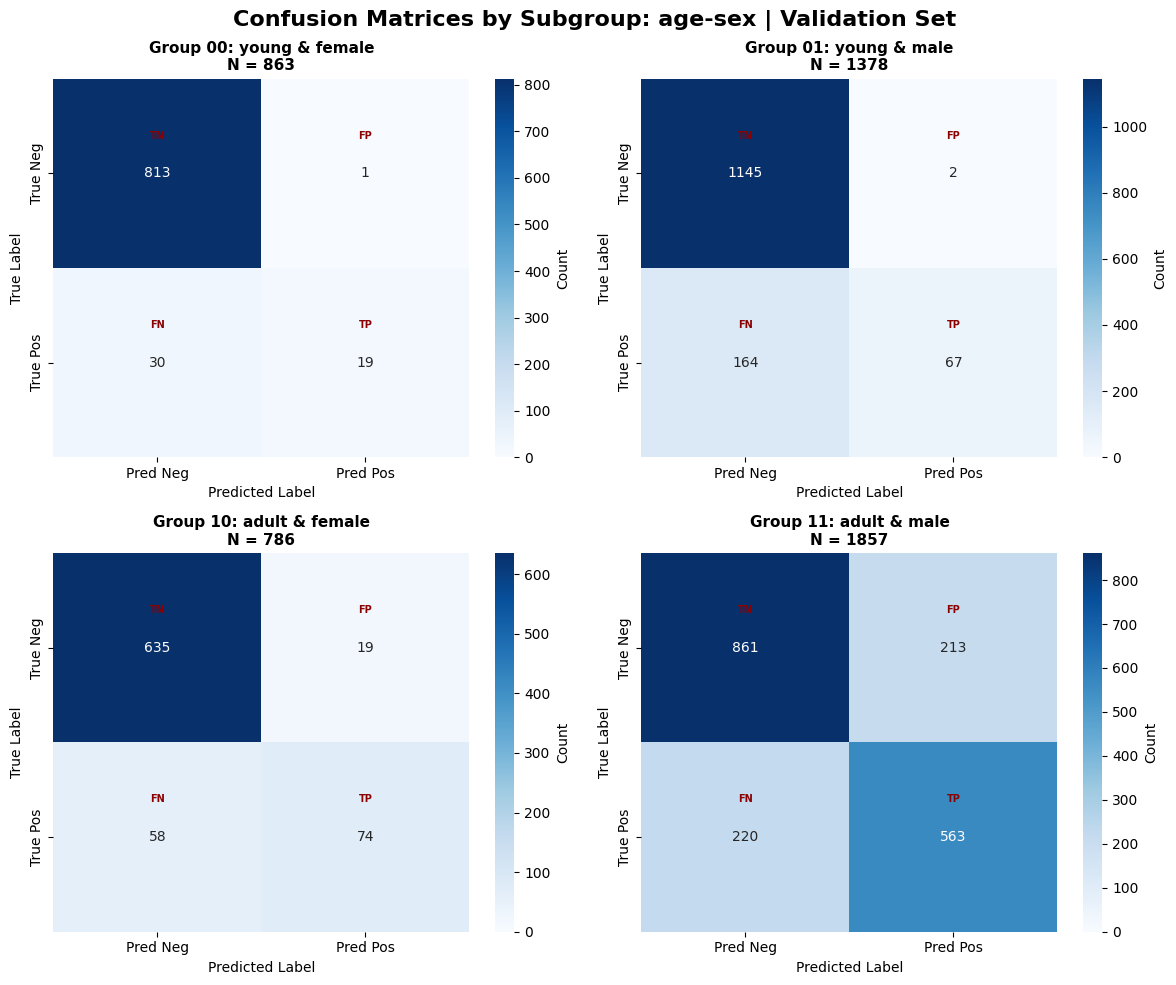

In [9]:
plot_confusion_matrix(cm_dict_val[sensible_attribute], '| Validation Set')

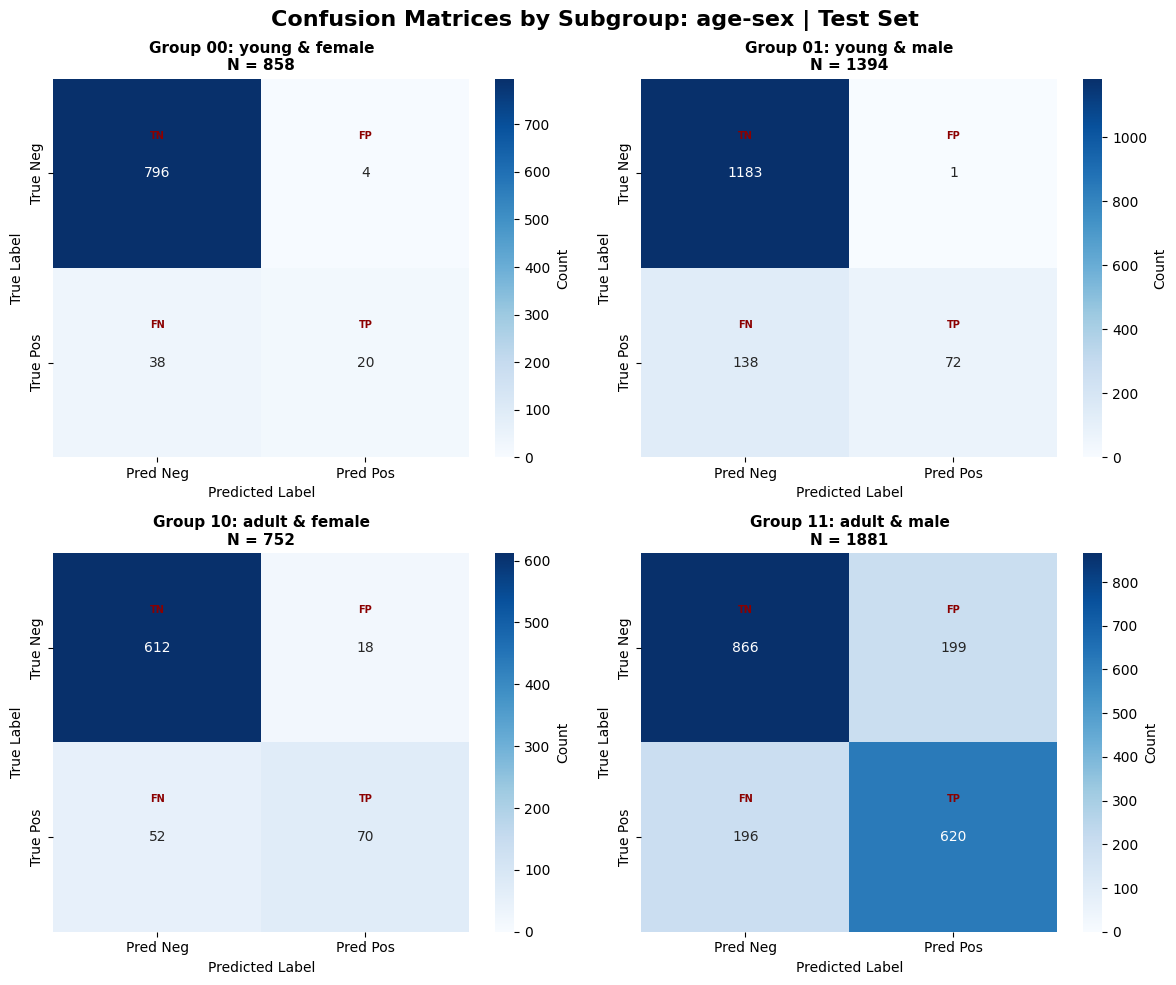

In [10]:
plot_confusion_matrix(cm_dict_test[sensible_attribute], '| Test Set')

# Compute Penalties: Validation and Test

Compute harmonic, geometric and arithmetic penalties, but only use harmonic for simplicity

In [11]:
# Compute BASELINE penalties on TEST set (Model 1 predictions)
penalties_ontest = {}
penalties_onval = {}
df_original = pd.read_csv(dataset_path)
individual_attributes = sensible_attribute.split('-')

for m in fair_metrics:
    # penalty_harm, penalty_geom, penalty_arith = compute_penalty_2(
    #     fairness_metrics_ontest_full, df_combined, 'sex', 'race', m
    # )
    penalties_ontest_harmonic, penalties_ontest_geometric, penalties_ontest_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test, df_original, individual_attributes[0], individual_attributes[1], m)

    penalties_ontest[m] = penalties_ontest_harmonic


    penalties_onval_harmonic, penalties_onval_geometric, penalties_onval_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_val, df_original, individual_attributes[0], individual_attributes[1], m)
    
    penalties_onval[m] = penalties_onval_harmonic
    
    # penalties_ontest[m] = {
    #     'harmonic': penalty_harm
    #     'geometric': penalty_geom,
    #     'arithmetic': penalty_arith
    # }

# Weights Functions

Three ways of calculating the weights, all **implemented** with the same function above (Model 2)

MAINLY FOCUSING ON NOTSIZED WEIGHTS.



### $w_i = 1 + \lambda * Penalty(g_i) $

This type of weight calculation has proven to be the most reliable and consistent, so we are mainly focusing on it during experiments.

In [12]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [13]:
def compute_weights_notsized(lambda_=5.0, m='FPN'):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized


In [14]:
# Keep a single standard weight for other parts of the notebook
weights_notsized = compute_weights_notsized(5.0)

Training samples: 22792, Unique weights per group: {'00': 1.5564516129032262, '01': 4.418674698795181, '10': 1.3648678907299594, '11': 0.01}


### $w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [15]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [16]:
def compute_weights_sized(lambda_=1.0, m='PPE'):

    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))

    # # Calculate average weight per group from validation set
    # df['weight'] = weights
    group_counts2 = train_df[sensible_attribute].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_sized = weights_for_training

    return weights_sized

In [17]:
weights_sized = compute_weights_sized(10.0)

Training samples: 22792, Unique weights per group: {'00': 3.8866832150872015, '01': 5.284416792466446, '10': 0.26088775282861154, '11': 0.01}


---

In [18]:
def compute_fixed_weights(lambda_=5.0, m='FPN', fixed_weights=None):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }

    weights_notsized = fixed_weights # in the form of a dictionary {'00': weight1, '01': weight2, ...}

    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized

# Model 2: Fairness metrics and penalty after reweighting

## Function

To compute penalties for Model 2:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

**Weights were computed on validation set, then propagated to the training set based on group membership.** 

**Now we fit the model on training set with these weights and evaluate on test set.**

In [19]:
def compute_penalties_after_reweighting(weights, fairness_metric):
    # Train Model 2 ONLY on the combined attribute (sensible_attribute) with weights
    import xgboost as xgb
    
    # Convert string combinations to numeric codes for XGBoost
    X_train_numeric = X_train[sensible_attribute].copy()
    X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes
    
    X_test_numeric = X_test[sensible_attribute].copy()
    X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes
    
    # Train model with weights on combined attribute
    model_reweighed = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_reweighed.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
    
    # Predict on test set
    y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)
    
    # Compute fairness metrics for ALL attributes (individual + combined)
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    fairness_metrics_dict_test_reweighed = {}
    
    for attribute in attributes:
        df = prepare_dataframe_for_attribute(dataset_path, attribute)
        
        # Compute sensible_indexes_test FRESH for this specific attribute
        sensible_indexes_test_attr = df[attribute].loc[list(X_test[attribute].index)]
        
        # Compute FAIRNESS METRICS for each attribute on TEST set
        # Use the SAME predictions (from combined attribute) for all attributes
        fairness_metrics_dict_test_reweighed[attribute], group_counts_test_reweighed, cm_dict_test_reweighed = \
        get_fairness_metrics(df, attribute, sensible_indexes_test_attr, \
        y_pred_test_reweighed_combined, y_test[attribute], X_test[attribute], \
        fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])

    individual_attributes = sensible_attribute.split('-')
    df_original = pd.read_csv(dataset_path)

    penalties_ontest_reweighed_harmonic, penalties_ontest_reweighed_geometric, penalties_ontest_reweighed_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test_reweighed, df_original, individual_attributes[0], individual_attributes[1], fairness_metric)

    return penalties_ontest_reweighed_harmonic

### Example

In [20]:
weights_notsized = compute_weights_notsized(5.0, 'FPN')
compute_penalties_after_reweighting(weights_notsized, 'FPN')

Training samples: 22792, Unique weights per group: {'00': 1.5564516129032262, '01': 4.418674698795181, '10': 1.3648678907299594, '11': 0.01}


{np.int64(1): array([[1475,  220],
       [ 259,  679]]), np.int64(0): array([[1969,   15],
       [ 167,  101]])}
{np.int64(0): array([[1408,   22],
       [  88,   92]]), np.int64(1): array([[2036,  213],
       [ 338,  688]])}
{'10': array([[611,  19],
       [ 51,  71]]), '00': array([[797,   3],
       [ 37,  21]]), '11': array([[864, 201],
       [208, 608]]), '01': array([[1172,   12],
       [ 130,   80]])}


{'00': 35.75,
 '01': 37.80202340805397,
 '10': 2.594155844155837,
 '11': -17.064738956074752}

---

# Penalty After Reweighting Plots

### Utils

In [21]:
penalties_ontest_after_reweighting = {}
cm_dict_reweighted = {}

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    # print("FAIRNESS METRIC:", metric)
    weights_notsized = compute_weights_notsized(5.0, metric)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty
    # print("\n")

Training samples: 22792, Unique weights per group: {'00': 1.5564516129032262, '01': 4.418674698795181, '10': 1.3648678907299594, '11': 0.01}


{np.int64(1): array([[1475,  220],
       [ 259,  679]]), np.int64(0): array([[1969,   15],
       [ 167,  101]])}
{np.int64(0): array([[1408,   22],
       [  88,   92]]), np.int64(1): array([[2036,  213],
       [ 338,  688]])}
{'10': array([[611,  19],
       [ 51,  71]]), '00': array([[797,   3],
       [ 37,  21]]), '11': array([[864, 201],
       [208, 608]]), '01': array([[1172,   12],
       [ 130,   80]])}


Training samples: 22792, Unique weights per group: {'00': 4.2688882063882065, '01': 3.818080176951145, '10': 0.12799219656226923, '11': 0.01}


{np.int64(1): array([[1464,  231],
       [ 251,  687]]), np.int64(0): array([[1969,   15],
       [ 170,   98]])}
{np.int64(0): array([[1404,   26],
       [  87,   93]]), np.int64(1): array([[2029,  220],
       [ 334,  692]])}
{'10': array([[610,  20],
       [ 52,  70]]), '00': array([[794,   6],
       [ 35,  23]]), '11': array([[854, 211],
       [199, 617]]), '01': array([[1175,    9],
       [ 135,   75]])}


Training samples: 22792, Unique weights per group: {'00': 3.7030887855387813, '01': 2.3726525199533004, '10': 0.829804828054539, '11': 0.01}
{np.int64(1): array([[1480,  215],
       [ 260,  678]]), np.int64(0): array([[1972,   12],
       [ 172,   96]])}


...

{np.int64(0): array([[1424,    6],
       [ 113,   67]]), np.int64(1): array([[2008,  241],
       [ 310,  716]])}
{'10': array([[627,   3],
       [ 77,  45]]), '00': array([[797,   3],
       [ 36,  22]]), '11': array([[859, 206],
       [197, 619]]), '01': array([[1149,   35],
       [ 113,   97]])}


Training samples: 22792, Unique weights per group: {'00': 3.354026881736954, '01': 0.03431887684427559, '10': 0.6975544246536622, '11': 0.5660207480347492}


{np.int64(1): array([[1474,  221],
       [ 246,  692]]), np.int64(0): array([[1960,   24],
       [ 160,  108]])}
{np.int64(0): array([[1406,   24],
       [  88,   92]]), np.int64(1): array([[2028,  221],
       [ 318,  708]])}
{'10': array([[609,  21],
       [ 50,  72]]), '00': array([[797,   3],
       [ 38,  20]]), '11': array([[865, 200],
       [196, 620]]), '01': array([[1163,   21],
       [ 122,   88]])}


Training samples: 22792, Unique weights per group: {'00': 4.138180764774043, '01': 3.912819840885879, '10': 0.3288721812757748, '11': 0.01}


{np.int64(1): array([[1460,  235],
       [ 250,  688]]), np.int64(0): array([[1972,   12],
       [ 172,   96]])}
{np.int64(0): array([[1406,   24],
       [  87,   93]]), np.int64(1): array([[2026,  223],
       [ 335,  691]])}
{'10': array([[610,  20],
       [ 50,  72]]), '00': array([[796,   4],
       [ 37,  21]]), '11': array([[850, 215],
       [200, 616]]), '01': array([[1176,    8],
       [ 135,   75]])}


## Penalty before and after reweighting

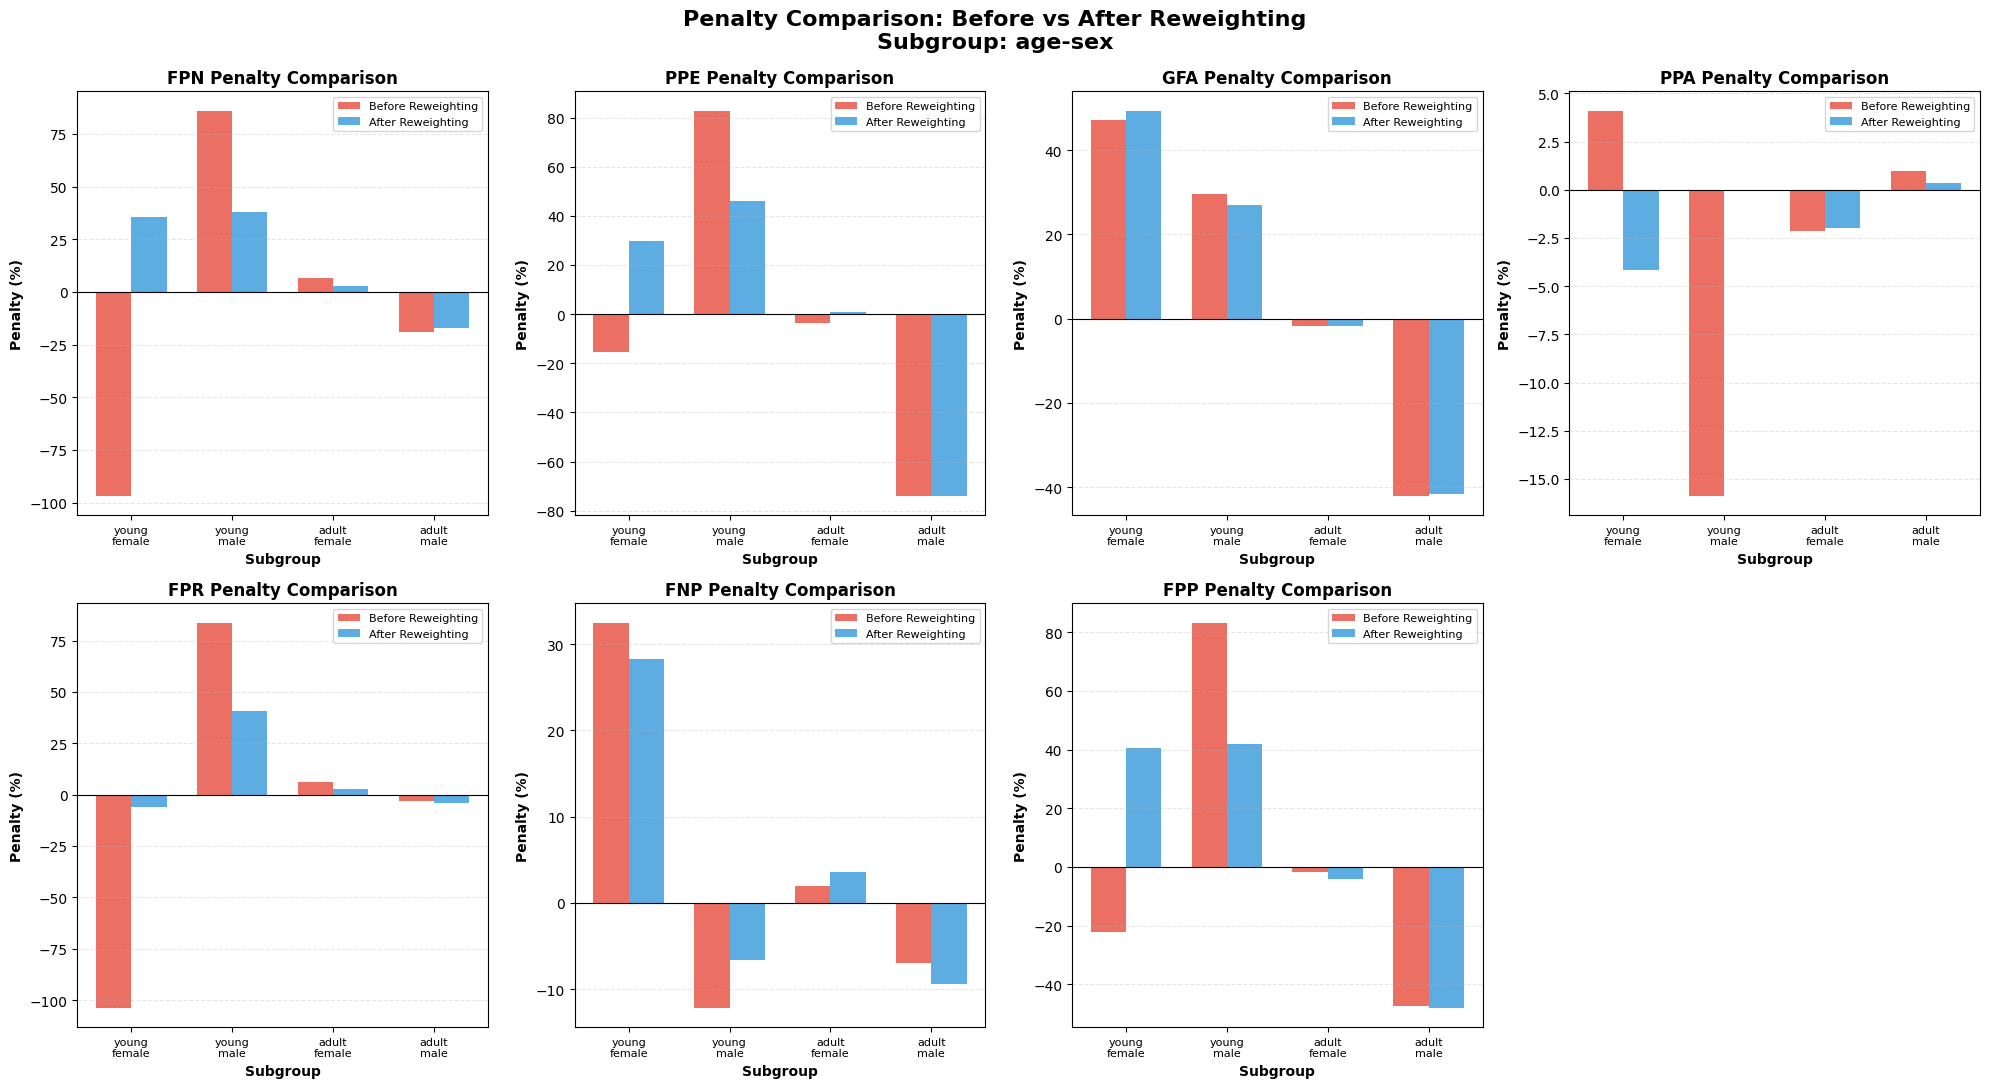

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping):
    """
    Generalized version that works with any subgroup combination.
    
    Args:
        fair_metrics: List of fairness metrics to plot
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_ontest_after_reweighting: Dictionary of penalties after reweighting
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups (assuming all metrics have the same subgroups)
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Set up the plot
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    # Create a bar plot for each metric
    for idx, metric in enumerate(fair_metrics):
        ax = axes[idx]
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    # Remove extra subplots if any
    for idx in range(len(fair_metrics), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison: Before vs After Reweighting\nSubgroup: {sensible_attribute}', 
                fontsize=16, fontweight='bold', y=1.03)
    plt.show()

# Use the generalized function
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                        sensible_attribute, mapping)

In [23]:
# lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

# for l in lambdas:
#     penalties_ontest_after_reweighting = {}

#     fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
#     for metric in fair_metrics:
#         # print("FAIRNESS METRIC:", metric)
#         weights_notsized = compute_weights_notsized(l, metric)
#         penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty
#         # print("\n")

#     fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
#     plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
#                                             sensible_attribute, mapping)

In [24]:
# Individual plots for each metric (larger view for detailed inspection)
def plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping):
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())

    for metric in fair_metrics:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        individual_attrs = sensible_attribute.split('-')
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
       
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=12, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(decoded_labels, fontsize=10)
        ax.legend(fontsize=11, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        
        plt.tight_layout()
        plt.show()
        print(f"\n{metric} - Penalty Changes:")
        for i, group in enumerate(subgroups):
            before = penalties_before[i]
            after = penalties_after[i]
            change = after - before
            print(f"  {decoded_labels[i].replace(chr(10), '-')}: {before:.2f} → {after:.2f} (Δ = {change:+.2f})")
        print("-" * 60)

Training samples: 22792, Unique weights per group: {'00': 1.2225806451612904, '01': 2.3674698795180724, '10': 1.1459471562919838, '11': 0.5828223301744047}
{np.int64(1): array([[1472,  223],
       [ 244,  694]]), np.int64(0): array([[1974,   10],
       [ 174,   94]])}


{np.int64(0): array([[1407,   23],
       [  90,   90]]), np.int64(1): array([[2039,  210],
       [ 328,  698]])}
{'10': array([[611,  19],
       [ 51,  71]]), '00': array([[796,   4],
       [ 39,  19]]), '11': array([[861, 204],
       [193, 623]]), '01': array([[1178,    6],
       [ 135,   75]])}


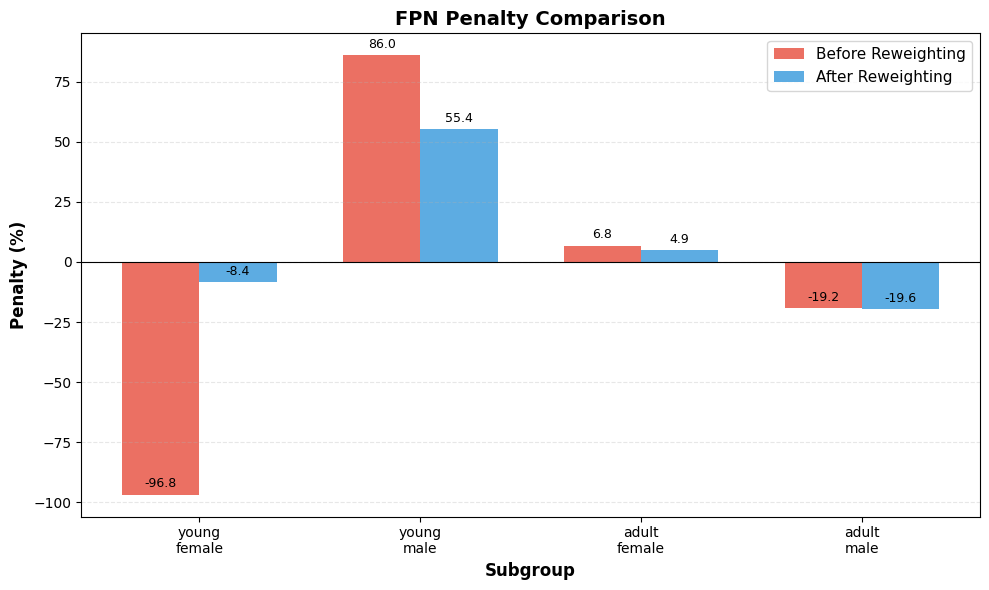


FPN - Penalty Changes:
  young-female: -96.84 → -8.43 (Δ = +88.41)
  young-male: 86.04 → 55.40 (Δ = -30.64)
  adult-female: 6.80 → 4.90 (Δ = -1.90)
  adult-male: -19.20 → -19.63 (Δ = -0.43)
------------------------------------------------------------


In [25]:
metrics = ['FPN']
penalties_ontest_after_reweighting = {}
for metric in metrics:
    weights_notsized = compute_weights_notsized(2, metric)
    penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty

plot_penalty_comparison_all_individual(metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping)